# Visual NLP 6.4.0 latest DICOM features
Let's analyze multiple additons.</br>
* Compression.
* Frame Sampling.
* DicomPretrainedPipeline.
* Faster Text Detection.
* And more!

For more details about Dicom de-identification please read:

 - [DICOM de-identification at scale in Visual NLP — Part 1.](https://medium.com/john-snow-labs/dicom-de-identification-at-scale-in-visual-nlp-part-1-68784177f5f0)

 - [DICOM de-identification at scale in Visual NLP — Part 2.](https://medium.com/john-snow-labs/dicom-de-identification-at-scale-in-visual-nlp-part-2-361af5e36412)

 - [DICOM de-identification at scale in Visual NLP — Part 3.](https://medium.com/john-snow-labs/dicom-de-identification-at-scale-in-visual-nlp-part-3-61cecc3adb56)

In [1]:
license = ""
secret = ""
aws_access_key = ""
aws_secret_key = ""

version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

## Initialization of spark session

In [2]:
from sparkocr import start
import os
import sys

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key


spark = start(jar_path=spark_ocr_jar_path, nlp_internal='6.4.0', nlp_secret='6.4.0-xyz')

spark

Spark version: 3.4.0
Spark NLP version: 6.4.0
Spark NLP for Healthcare version: 6.4.0
Spark OCR version: 6.4.0



## Import Spark OCR transformers

In [3]:
import pandas as pd

import sparkocr
from sparkocr.transformers import *
from sparkocr.utils import *
from sparkocr.enums import *
import pyspark.sql.functions as f

from pyspark.ml import PipelineModel, Pipeline

## Read dicom objects as binary file and display metadata
We will be using a sample DICOM file for this, let's first visualize the images and metadata.


In [27]:
import pkg_resources
dicom_path = '../../workshop/jupyter/data/dicom/sarah_evans.dcm'
dicom_df = spark.read.format("binaryFile").load(dicom_path)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## Show original DICOM

11:12:46, INFO Error while sending or receiving.
Traceback (most recent call last):
  File "/home/jose/.local/lib/python3.8/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer
11:12:46, INFO Closing down clientserver connection
11:12:46, INFO Exception while sending command.
Traceback (most recent call last):
  File "/home/jose/.local/lib/python3.8/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/jose/.local/lib/python3.8/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/jose/.local/lib/python3.8/site-packages/py4j/clientserver.py", line 506, in send_command

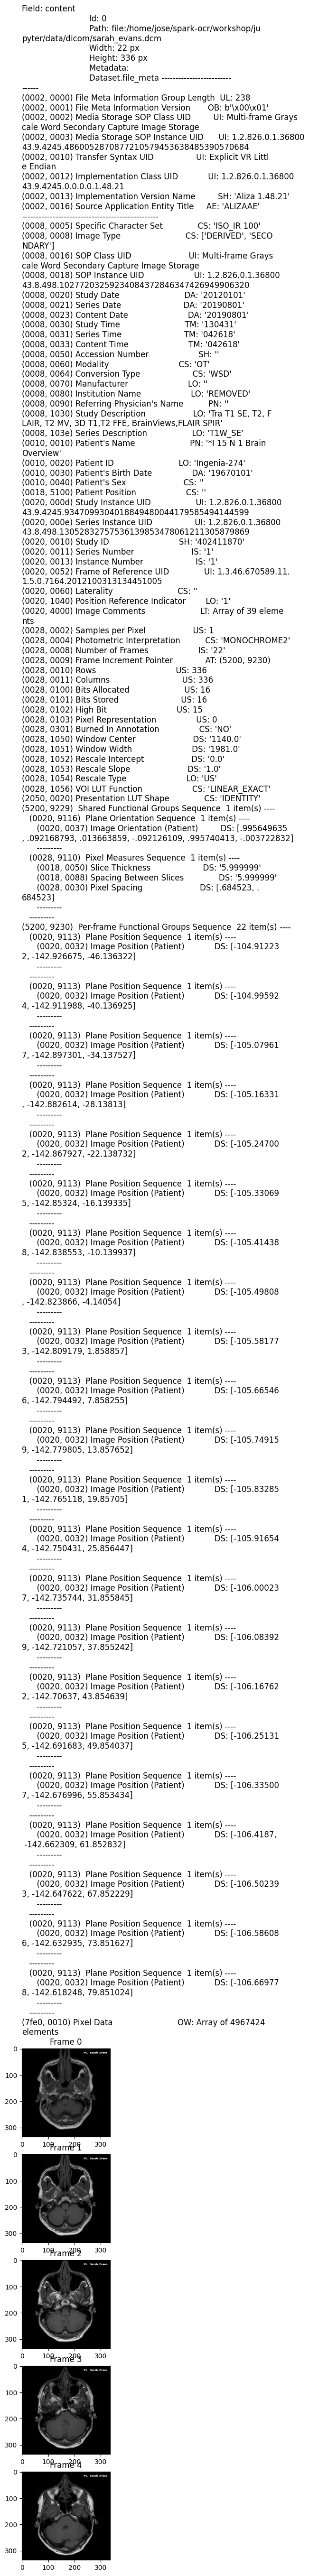

In [28]:
display_dicom(dicom_df, "content")

## Let's read the metadata into a Spark Dataframe
'metadata' column will contain it as a string

In [8]:
dicom = DicomToMetadata() \
    .setInputCol("content") \
    .setOutputCol("metadata")

result = dicom.transform(dicom_df).cache()
print(result.select("metadata").collect()[0].metadata)

/home/jose/.local/lib/python3.8/site-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


{
    "00080005": {
        "tag": "00080005",
        "vr": "CS",
        "value": "ISO_IR 100"
    },
    "00080008": {
        "tag": "00080008",
        "vr": "CS",
        "value": [
            "DERIVED",
            "SECONDARY"
        ]
    },
    "00080016": {
        "tag": "00080016",
        "vr": "UI",
        "value": "1.2.840.10008.5.1.4.1.1.7.3"
    },
    "00080018": {
        "tag": "00080018",
        "vr": "UI",
        "value": "1.2.826.0.1.3680043.8.498.31780752671805165188251122103481497997"
    },
    "00080020": {
        "tag": "00080020",
        "vr": "DA",
        "value": "20120101"
    },
    "00080021": {
        "tag": "00080021",
        "vr": "DA",
        "value": "20190801"
    },
    "00080023": {
        "tag": "00080023",
        "vr": "DA",
        "value": "20190801"
    },
    "00080030": {
        "tag": "00080030",
        "vr": "TM",
        "value": "130431"
    },
    "00080031": {
        "tag": "00080031",
        "vr": "TM",
        "v

## Build Pipeline from scratch
### NLP part

In [13]:
from sparknlp.annotator import *
from sparknlp.base import *
import sparknlp_jsl
from sparknlp_jsl.annotator import *

In [9]:
def deidentification_nlp_pipeline(input_column, prefix = "", model="ner_deid_large"):
    document_assembler = DocumentAssembler() \
        .setInputCol(input_column) \
        .setOutputCol(prefix + "document_raw")

    cleanUpPatterns = ["<[^>]>"]
    documentNormalizer = DocumentNormalizer() \
      .setInputCols(prefix + "document_raw") \
      .setOutputCol(prefix + "document") \
      .setAction("clean") \
      .setPatterns(cleanUpPatterns) \
      .setReplacement(" ") \
      .setPolicy("pretty_all")

    # Sentence Detector annotator, processes various sentences per line
    sentence_detector = SentenceDetector() \
        .setInputCols([prefix + "document"]) \
        .setOutputCol(prefix + "sentence")

    tokenizer = Tokenizer() \
        .setInputCols([prefix + "sentence"]) \
        .setOutputCol(prefix + "token")

    # Clinical word embeddings
    word_embeddings = WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models") \
        .setInputCols([prefix + "sentence", prefix + "token"]) \
        .setOutputCol(prefix + "embeddings")

    clinical_ner = MedicalNerModel.pretrained(model, "en", "clinical/models") \
        .setInputCols([prefix + "sentence", prefix + "token", prefix + "embeddings"]) \
        .setOutputCol(prefix + "ner")

    custom_ner_converter = NerConverter() \
        .setInputCols([prefix + "sentence", prefix + "token", prefix + "ner"]) \
        .setOutputCol(prefix + "ner_chunk") \
        .setWhiteList(['NAME', 'AGE', 'CONTACT',
                   'LOCATION', 'PROFESSION', 'PERSON', 'DATE', 'ID','DOCTOR'])
    
    # here we merge the rule based approach `entity` with the ML approach `ner_chunk`
    chunk_merge = ChunkMergeApproach()\
        .setInputCols("entity","ner_chunk")\
        .setOutputCol("deid_merged_chunk")

    nlp_pipeline = Pipeline(stages=[
            document_assembler,
            documentNormalizer,
            sentence_detector,
            tokenizer,
            word_embeddings,
            clinical_ner,
            custom_ner_converter,
            chunk_merge
        ])
    empty_data = spark.createDataFrame([[""]]).toDF(input_column)
    nlp_model = nlp_pipeline.fit(empty_data)
    return nlp_model

In [19]:
from sparknlp.pretrained import PretrainedPipeline

def deidentification_nlp_pipeline(input_column, prefix = "", model="ner_deid_large"):
    document_assembler = DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

    sentence_detector = SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

    tokenizer = Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

    labels =["DOCTOR", "PATIENT", "AGE", "DATE", "HOSPITAL", "CITY", "STREET", "STATE", "COUNTRY", "PHONE", "IDNUM", "EMAIL", "ZIP", "ORGANIZATION", "PROFESSION", "USERNAME"]

    pretrained_zero_shot_ner = PretrainedZeroShotNER().pretrained("zeroshot_ner_deid_subentity_merged_large", "en", "clinical/models")\
    .setInputCols("sentence", "token")\
    .setOutputCol("ner")\
    .setPredictionThreshold(0.5)\
    .setLabels(labels)

    ner_converter = NerConverterInternal()\
    .setInputCols("sentence", "token", "ner")\
    .setOutputCol("deid_merged_chunk")

    pipeline = Pipeline().setStages([
    document_assembler,
    sentence_detector,
    tokenizer,
    pretrained_zero_shot_ner,
    ner_converter
    ])

    empty_data = spark.createDataFrame([[""]]).toDF(input_column)
    nlp_model = pipeline.fit(empty_data)

    return nlp_model

### Visual part

In [20]:
from pyspark.ml import PipelineModel, Pipeline
from sparkocr.enums import *

dicom_to_metadata = DicomToMetadata() \
    .setInputCol("content") \
    .setOutputCol("metadata") \
    .setKeepInput(True)

dicom_to_image = DicomToImageV3() \
    .setInputCols(["content"]) \
    .setOutputCol("image_raw") \
    .setKeepInput(True) \
    .setFrameLimit(4) \
    .setFrameSamplingStrategy(FrameSamplingStrategy.STRIDE) \
    .setFrameDimsCol("frame_dims") 

# files are compressed if Megapixel >= compressionThreshold
dicom_to_image.setCompressionMode('auto')

text_detector = ImageTextDetectorV2 \
    .pretrained("image_text_detector_v2", "en", "clinical/ocr") \
    .setInputCol("image_raw") \
    .setOutputCol("text_regions") \
    .setWidth(300) \
    .setWithRefiner(False) \
    .setLinkThreshold(0.7)

ocr = ImageToTextV3() \
    .setInputCols(["image_raw", "text_regions"]) \
    .setOutputCol("text")

deidentifier = DicomDeidentifier() \
    .setInputCols(["positions", "metadata"]) \
    .setOutputCol("entity") \
    .setKeepInput(True) \
    .setBlackList(["acc"])

# converts entities to bounding boxes' coordinates
position_finder = PositionFinder() \
    .setInputCols(["deid_merged_chunk"]) \
    .setOutputCol("coordinates") \
    .setPageMatrixCol("positions") \
    .setIgnoreSchema(True) \
    .setOcrScaleFactor(1.0)

# draws filled rectangle for hidding sensitive data
draw_regions = DicomDrawRegions() \
    .setInputCol("content") \
    .setInputRegionsCol("coordinates") \
    .setOutputCol("dicom") \
    .setAggCols(["path", "content"]) \
    .setKeepInput(True)

dicom_deidentifier = DicomMetadataDeidentifier() \
    .setInputCols(["dicom"]) \
    .setOutputCol("dicom_cleaned") \
    .setKeepInput(True)

# OCR pipeline
pipeline = PipelineModel(stages=[
    dicom_to_metadata,
    dicom_to_image,
    text_detector,
    ocr,
    deidentifier,
    # consider also model="ner_deid_generic_augmented"
    deidentification_nlp_pipeline(input_column="text", prefix="", model="ner_deid_sd"),
    position_finder,
    draw_regions, # comment last two stages for debug
    dicom_deidentifier
])

image_text_detector_v2 download started this may take some time.
Approximate size to download 75.3 MB
zeroshot_ner_deid_subentity_merged_large download started this may take some time.
Approximate size to download 1.5 GB
[OK!]


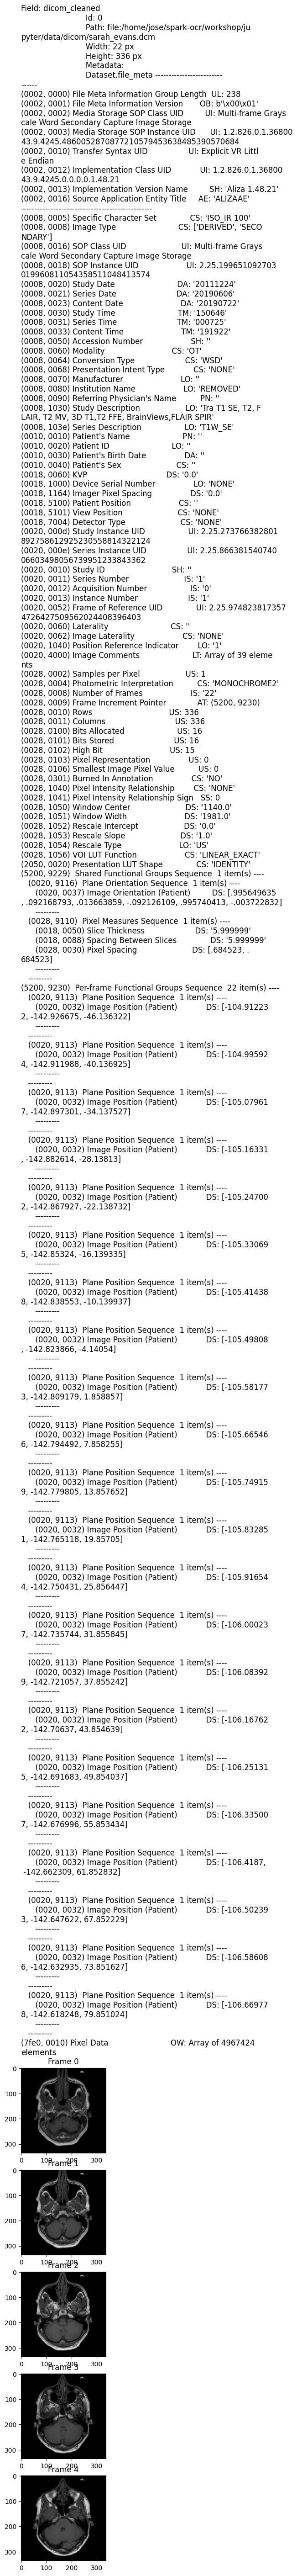

In [29]:
clean_dcm_df = pipeline.transform(dicom_df).cache()
display_dicom(clean_dcm_df, "dicom_cleaned")

In [14]:
clean_dcm_df.printSchema()

root
 |-- exception: string (nullable = true)
 |-- dicom_cleaned: binary (nullable = true)
 |-- dicom: binary (nullable = true)
 |-- path: string (nullable = true)
 |-- content: binary (nullable = true)



## Pull Dicom files

In [30]:
output_path = "./deidentified_dcms"
from pyspark.sql.functions import *

def get_name(path, keep_subfolder_level=0):
    path = path.split("/")
    path[-1] = path[-1].split('.')[0]
    return "/".join(path[-keep_subfolder_level-1:])

clean_dcm_df.withColumn("fileName", udf(get_name, StringType())(col("path"))) \
    .write \
    .format("binaryFormat") \
    .option("type", "dicom") \
    .option("field", "dicom_cleaned") \
    .option("prefix", "deid_") \
    .option("nameField", "fileName") \
    .mode("overwrite") \
    .save(output_path)

In [31]:
!ls deidentified_dcms

IOStream.flush timed out
deid_sarah_evans.dcm  _SUCCESS
